In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import deque

In [2]:
# ─────────────────────────────────────────────
# 1.  DATA GENERATOR  (simulates concept drift)
# ─────────────────────────────────────────────
def generate_stream(n_samples=2000, drift_at=1000, seed=42):
    """
    Phase 1 (0..drift_at):   Class 1 lives in top-right quadrant.
    Phase 2 (drift_at..end): Class 1 MOVES to bottom-left — concept drift!
    """
    rng = np.random.default_rng(seed)
    X, y = [], []

    for i in range(n_samples):
        if i < drift_at:
            # Class 1: top-right  |  Class 0: bottom-left
            label = rng.integers(0, 2)
            if label == 1:
                x1, x2 = rng.normal(0.7, 0.15), rng.normal(0.7, 0.15)
            else:
                x1, x2 = rng.normal(0.3, 0.15), rng.normal(0.3, 0.15)
        else:
            # DRIFT: Class 1 now lives in bottom-left
            label = rng.integers(0, 2)
            if label == 1:
                x1, x2 = rng.normal(0.3, 0.15), rng.normal(0.3, 0.15)
            else:
                x1, x2 = rng.normal(0.7, 0.15), rng.normal(0.7, 0.15)
        X.append([x1, x2])
        y.append(label)

    return np.array(X), np.array(y)



In [12]:
# ─────────────────────────────────────────────
# 2.  DYNAMIC RANDOM FOREST
# ─────────────────────────────────────────────
class DynamicRandomForest:
    """
    Tree-replacement DRF:
    - Maintains a pool of at most `max_trees` trees.
    - Trains a new tree every `retrain_every` samples on the last `window` samples.
    - Replaces the OLDEST tree when the pool is full.
    - Uses weighted voting: recent trees get higher weight.
    """
    def __init__(self, max_trees=10, window=200, retrain_every=100):
        self.max_trees   = max_trees
        self.window      = window
        self.retrain_every = retrain_every
        self.trees       = deque()          # (tree, age)  oldest → left
        self.X_buf       = deque(maxlen=window)
        self.y_buf       = deque(maxlen=window)
        self.step        = 0

    def _train_new_tree(self):
        X = np.array(self.X_buf)
        y = np.array(self.y_buf)
        tree = DecisionTreeClassifier(max_depth=4,
                                      max_features="sqrt",
                                      random_state=self.step)
        tree.fit(X, y)
        return tree
    def update(self, x, label):
        """Ingest one new sample; maybe retrain."""
        self.X_buf.append(x)
        self.y_buf.append(label)
        self.step += 1

        # Age every existing tree
        self.trees = deque([(t, age + 1) for t, age in self.trees])

        if self.step % self.retrain_every == 0 and len(self.X_buf) >= 50:
            new_tree = self._train_new_tree()
            if len(self.trees) >= self.max_trees:
                self.trees.popleft()          # evict oldest
            self.trees.append((new_tree, 0))  # add newest (age=0)

    def predict(self, X):
        if not self.trees:
            return np.zeros(len(X), dtype=int)
        # Weight = 1 / (age + 1)  → newer trees vote louder
        votes = np.zeros((len(X), 2))
        for tree, age in self.trees:
            w = 1.0 / (age + 1)
            proba = tree.predict_proba(X)
            votes += w * proba
        return np.argmax(votes, axis=1)


In [ ]:
# ─────────────────────────────────────────────
# 3.  SIMULATION
# ─────────────────────────────────────────────
N          = 2000
DRIFT_AT   = 1000
WARM_UP    = 200    # need this many samples before evaluating
EVAL_EVERY = 50     # evaluate accuracy every N steps
WINDOW     = 100    # rolling accuracy window

X, y = generate_stream(N, DRIFT_AT)

# --- Static RF: trained only on pre-drift data ---
rf = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=0)
rf.fit(X[:DRIFT_AT // 2], y[:DRIFT_AT // 2])   # trained on first 500 samples

# --- Dynamic RF ---
drf = DynamicRandomForest(max_trees=10, window=200, retrain_every=100)

rf_acc, drf_acc, timesteps = [], [], []
rf_window, drf_window = deque(maxlen=WINDOW), deque(maxlen=WINDOW)

for i in range(N):
    xi = X[i].reshape(1, -1)
    yi = y[i]

    # Predict before updating DRF
    if len(drf.trees) > 0:
        drf_pred = drf.predict(xi)[0]
        drf_window.append(int(drf_pred == yi))

    rf_pred = rf.predict(xi)[0]
    rf_window.append(int(rf_pred == yi)) #boolean accuracy (1 if correct, 0 if wrong)

    # Update DRF with new sample
    drf.update(X[i], yi)

    if i >= WARM_UP and i % EVAL_EVERY == 0:
        timesteps.append(i)
        rf_acc.append(np.mean(rf_window))
        drf_acc.append(np.mean(drf_window) if drf_window else 0.0)

rf_acc  = np.array(rf_acc)
drf_acc = np.array(drf_acc)
timesteps = np.array(timesteps)



In [16]:
rf_acc


array([0.98, 0.98, 0.98, 0.97, 0.98, 0.99, 0.99, 0.96, 0.96, 0.98, 0.99,
       0.98, 0.96, 0.95, 0.96, 0.95, 0.92, 0.47, 0.01, 0.01, 0.03, 0.02,
       0.01, 0.02, 0.02, 0.02, 0.03, 0.02, 0.01, 0.03, 0.05, 0.05, 0.03,
       0.02, 0.04, 0.05])

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/rf_vs_drf.png'

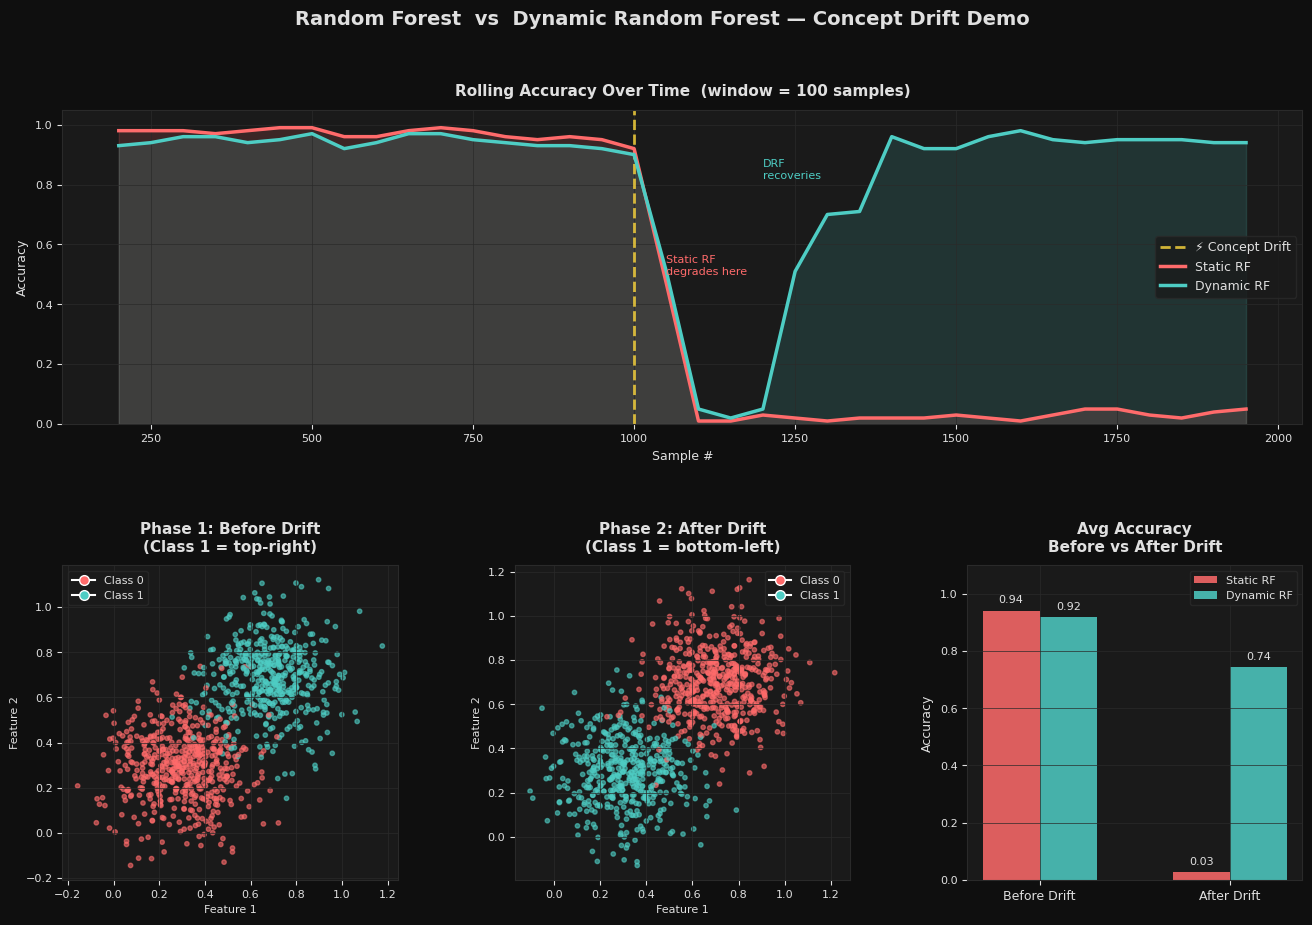

In [14]:
# ─────────────────────────────────────────────
# 4.  VISUALISATION
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor="#0f0f0f")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ACCENT_RF  = "#ff6b6b"
ACCENT_DRF = "#4ecdc4"
DRIFT_CLR  = "#ffd93d"
BG         = "#0f0f0f"
PANEL      = "#1a1a1a"
TEXT       = "#e0e0e0"
GRID       = "#2a2a2a"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=10)
    ax.tick_params(colors=TEXT, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(color=GRID, linewidth=0.5)

# --- Plot 1: Accuracy over time ---
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, "Rolling Accuracy Over Time  (window = 100 samples)")
ax1.axvline(DRIFT_AT, color=DRIFT_CLR, linewidth=2, linestyle="--", alpha=0.8, label="⚡ Concept Drift")
ax1.plot(timesteps, rf_acc,  color=ACCENT_RF,  linewidth=2.5, label="Static RF")
ax1.plot(timesteps, drf_acc, color=ACCENT_DRF, linewidth=2.5, label="Dynamic RF")
ax1.fill_between(timesteps, rf_acc,  alpha=0.15, color=ACCENT_RF)
ax1.fill_between(timesteps, drf_acc, alpha=0.15, color=ACCENT_DRF)
ax1.set_xlabel("Sample #", color=TEXT, fontsize=9)
ax1.set_ylabel("Accuracy", color=TEXT, fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
ax1.annotate("Static RF\ndegrades here", xy=(DRIFT_AT + 50, 0.5),
             color=ACCENT_RF, fontsize=8, ha="left")
ax1.annotate("DRF\nrecoveries", xy=(DRIFT_AT + 200, 0.82),
             color=ACCENT_DRF, fontsize=8, ha="left")

# --- Scatter helpers ---
def scatter_phase(ax, X, y, idx, title):
    style_ax(ax, title)
    colors = [ACCENT_RF if yi == 0 else ACCENT_DRF for yi in y[idx]]
    ax.scatter(X[idx, 0], X[idx, 1], c=colors, s=10, alpha=0.6)
    ax.set_xlabel("Feature 1", color=TEXT, fontsize=8)
    ax.set_ylabel("Feature 2", color=TEXT, fontsize=8)
    from matplotlib.lines import Line2D
    legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor=ACCENT_RF,  markersize=7, label='Class 0'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor=ACCENT_DRF, markersize=7, label='Class 1')]
    ax.legend(handles=legend, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=8)

pre_idx  = np.arange(0, DRIFT_AT)
post_idx = np.arange(DRIFT_AT, N)

ax2 = fig.add_subplot(gs[1, 0])
scatter_phase(ax2, X, y, pre_idx,  "Phase 1: Before Drift\n(Class 1 = top-right)")

ax3 = fig.add_subplot(gs[1, 1])
scatter_phase(ax3, X, y, post_idx, "Phase 2: After Drift\n(Class 1 = bottom-left)")

# --- Bar: Average accuracy before/after drift ---
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4, "Avg Accuracy\nBefore vs After Drift")

mid = len(timesteps) // 2
before_rf   = rf_acc[:mid].mean()
after_rf    = rf_acc[mid:].mean()
before_drf  = drf_acc[:mid].mean()
after_drf   = drf_acc[mid:].mean()

x      = np.array([0, 1])
width  = 0.3
bars_rf  = ax4.bar(x - width/2, [before_rf,  after_rf],  width, color=ACCENT_RF,  alpha=0.85, label="Static RF")
bars_drf = ax4.bar(x + width/2, [before_drf, after_drf], width, color=ACCENT_DRF, alpha=0.85, label="Dynamic RF")
ax4.set_xticks(x)
ax4.set_xticklabels(["Before Drift", "After Drift"], color=TEXT, fontsize=9)
ax4.set_ylabel("Accuracy", color=TEXT, fontsize=9)
ax4.set_ylim(0, 1.1)
ax4.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=8)
for bar in list(bars_rf) + list(bars_drf):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha='center', va='bottom', color=TEXT, fontsize=8)

fig.suptitle("Random Forest  vs  Dynamic Random Forest — Concept Drift Demo",
             color=TEXT, fontsize=14, fontweight="bold", y=0.98)

plt.savefig("/mnt/user-data/outputs/rf_vs_drf.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
print("Saved → rf_vs_drf.png")

# ─────────────────────────────────────────────
# 5.  PRINT SUMMARY
# ─────────────────────────────────────────────
mid = len(timesteps) // 2
print("\n── Accuracy Summary ─────────────────────────")
print(f"{'':20s}  {'Before Drift':>14}  {'After Drift':>12}")
print(f"{'Static RF':20s}  {rf_acc[:mid].mean():>14.3f}  {rf_acc[mid:].mean():>12.3f}")
print(f"{'Dynamic RF':20s}  {drf_acc[:mid].mean():>14.3f}  {drf_acc[mid:].mean():>12.3f}")
print("─────────────────────────────────────────────")
print(f"\nDRF advantage after drift: +{(drf_acc[mid:].mean() - rf_acc[mid:].mean()):.3f}")
print(f"Trees in DRF pool at end:  {len(drf.trees)}")